## Legacy heuristic examples

`ClassicEW`, `CPEW`, `NBEW`, and `OBEW` are deprecated legacy heuristic entry points. They will be removed in version 0.3.

Their functionality is now available through the unified `constructor()` heuristic.

This notebook contains examples of each of the legacy entry points usage and the equivalent call to `constructor()`.

The unified heuristic **does not reproduce exactly** the deprecated heuristics, but the properties of the solution should match.

In [1]:
import warnings

from optiwindnet.importer import load_repository
from optiwindnet.mesh import make_planar_embedding
from optiwindnet.pathfinding import PathFinder
from optiwindnet.heuristics import ClassicEW, CPEW, NBEW, OBEW, constructor
from optiwindnet.interarraylib import G_from_S, calcload
from optiwindnet.svg import svgplot

In [2]:
locations = load_repository()

### Helper functions

The deprecated heuristics in this notebook (`ClassicEW`, `CPEW`, `NBEW`, and `OBEW`) take the location graph **L** as input and return a routed graph **G** directly. Hence, `legacy_solution()` only needs to call the legacy function and then calculate edge loads.

`constructor()` works one level lower in the routing pipeline. It's input is the available-links graph **A** and its return value is the solution topology **S**. That is why `constructor_solution()` first calls `make_planar_embedding(L)` to derive the planar mesh **P** and available links **A**, then calls `constructor(A, ...)`, converts **S** to a tentative graph with `G_from_S(S, A)`, and finally uses `PathFinder(...).create_detours()` to obtain the routed graph **G** used for plotting and comparison.

In [3]:
def legacy_solution(fun, L, capacity, **kwargs):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', DeprecationWarning)
        G = fun(L, capacity=capacity, **kwargs)
    calcload(G)
    return G

def constructor_solution(L, capacity, **kwargs):
    P, A = make_planar_embedding(L)
    S = constructor(A, capacity=capacity, **kwargs)
    G_topology = G_from_S(S, A)
    G = PathFinder(G_topology, planar=P, A=A).create_detours()
    calcload(G)
    return G

def compare(label, legacy, constructed):
    return {
        'case': label,
        'legacy_length': round(legacy.size(weight='length')),
        'constructor_length': round(constructed.size(weight='length')),
        'legacy_max_load': legacy.graph['max_load'],
        'constructor_max_load': constructed.graph['max_load'],
    }

def show_pair(label, legacy, constructed):
    print(f'{label}: legacy')
    display(svgplot(legacy))
    print(f'{label}: constructor')
    display(svgplot(constructed))

### Classic Esau-Williams

In [4]:
L = locations.merkur
capacity = 9

G_classic = legacy_solution(ClassicEW, L, capacity)
G_constructor_classic = constructor_solution(
    L,
    capacity,
    method='esau_williams',
    weigh_detours=False,
)

compare('ClassicEW', G_classic, G_constructor_classic)

{'case': 'ClassicEW',
 'legacy_length': 59585,
 'constructor_length': 60145,
 'legacy_max_load': 9,
 'constructor_max_load': 9}

ClassicEW: legacy


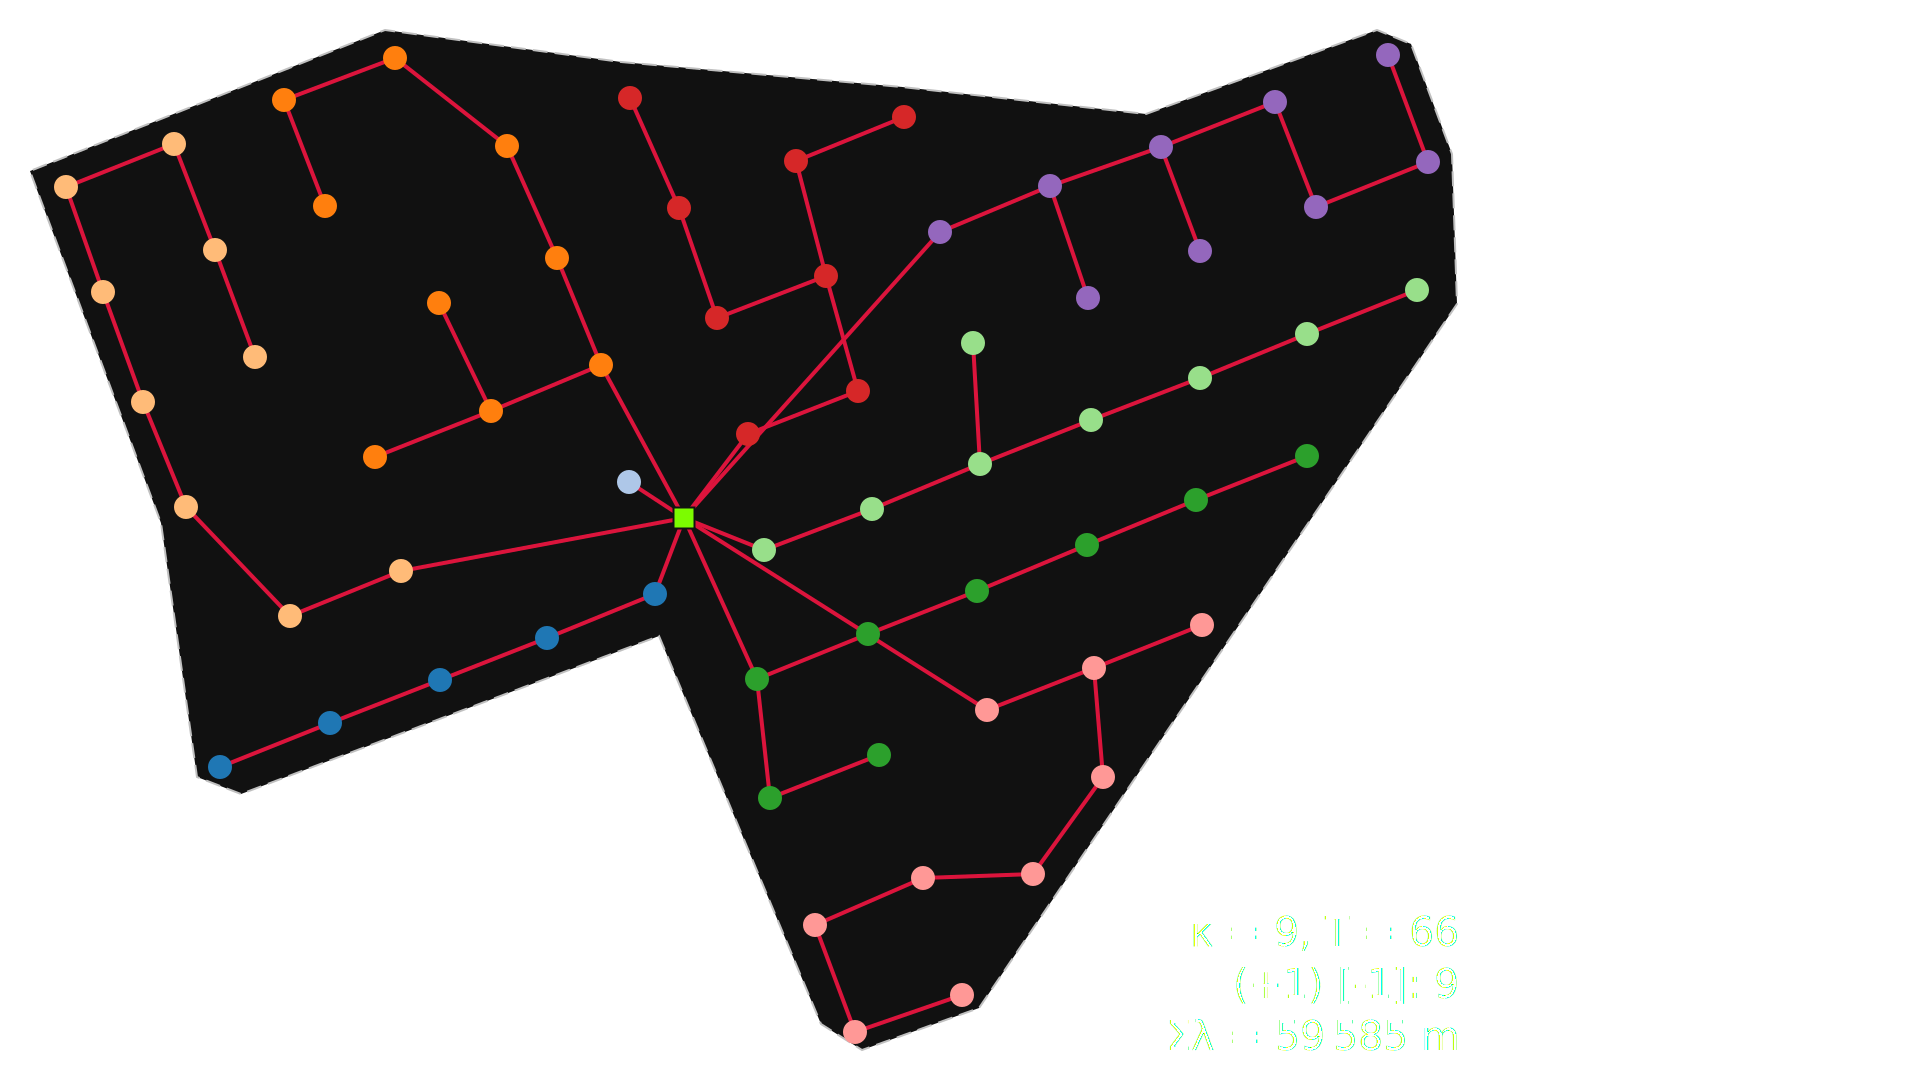

ClassicEW: constructor


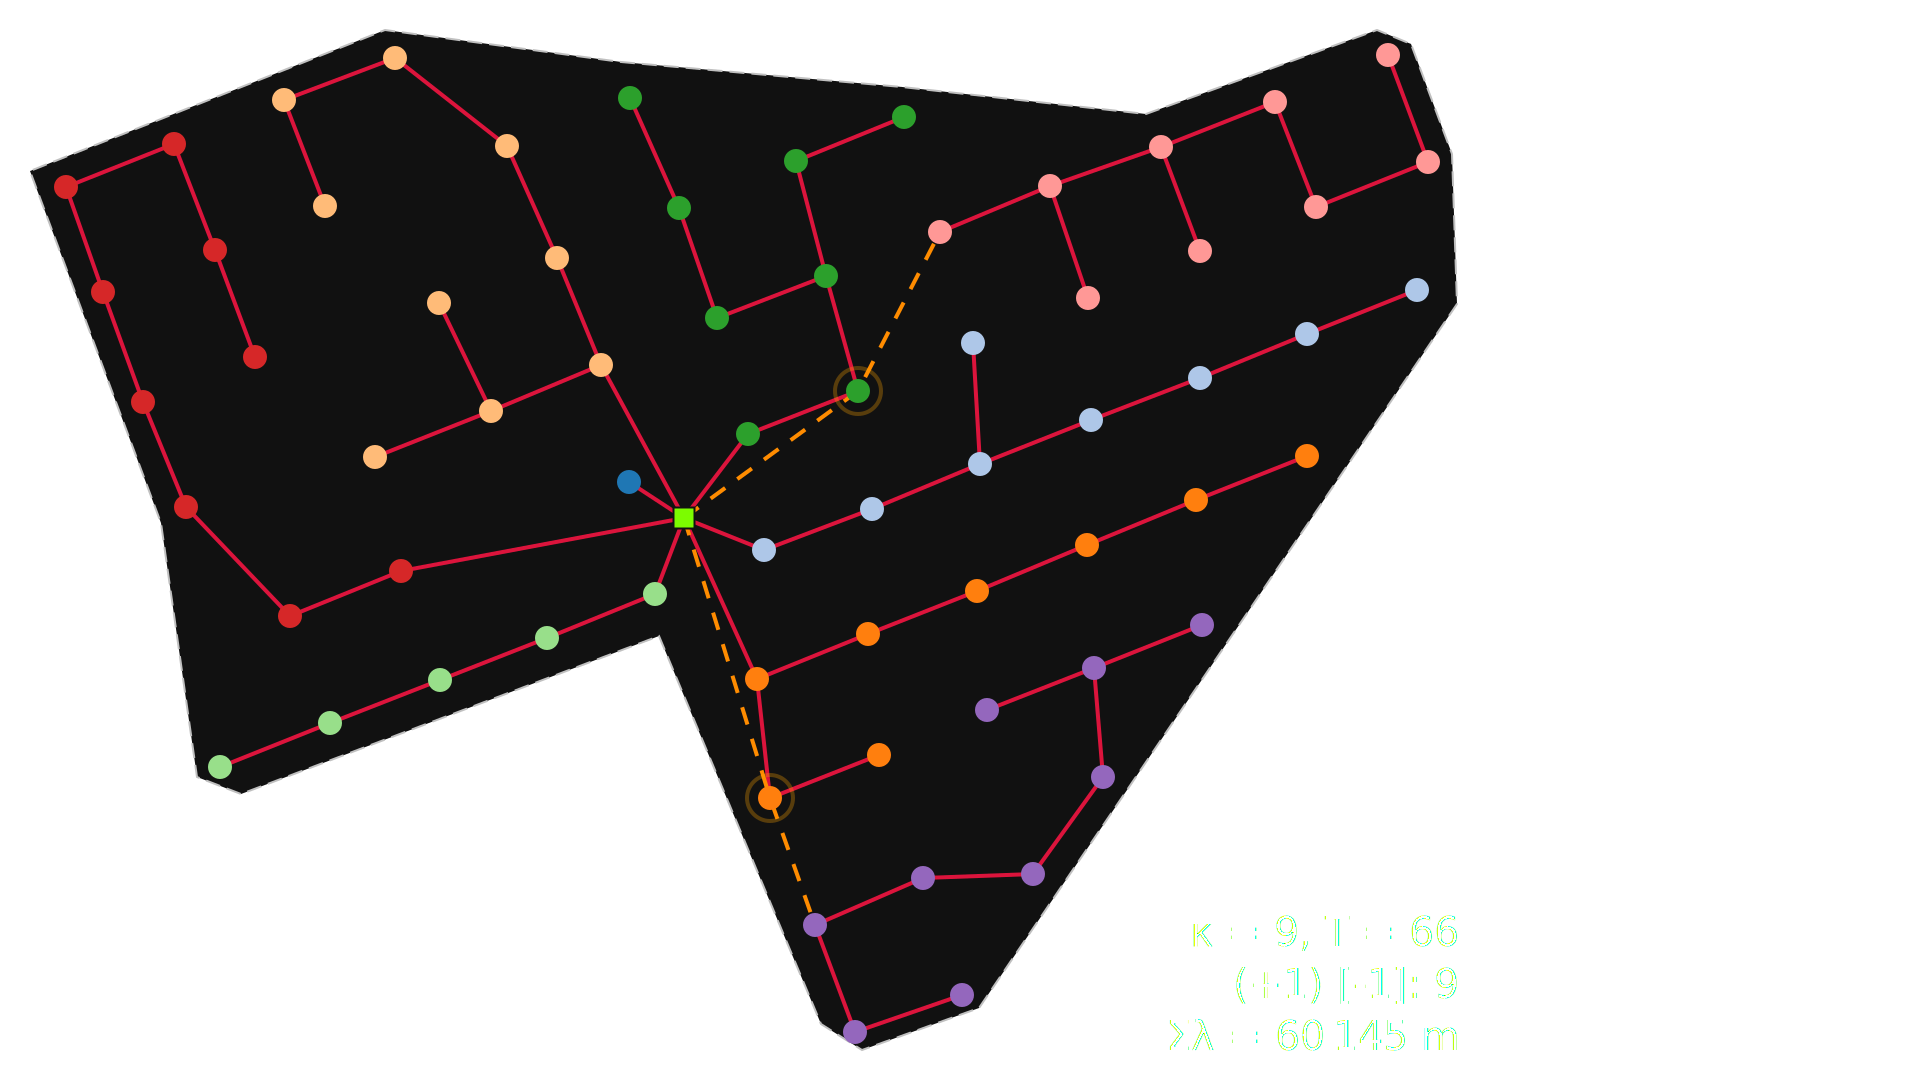

In [5]:
show_pair('ClassicEW', G_classic, G_constructor_classic)

### Crossing-Preventing Esau-Williams

In [6]:
L = locations.merkur
capacity = 9

G_cpew = legacy_solution(CPEW, L, capacity)
G_constructor_cpew = constructor_solution(
    L,
    capacity,
    method='biased_EW',
    straight_feeder_route=True,
    weigh_detours=False,
)

compare('CPEW', G_cpew, G_constructor_cpew)

{'case': 'CPEW',
 'legacy_length': 59922,
 'constructor_length': 59902,
 'legacy_max_load': 9,
 'constructor_max_load': 9}

CPEW: legacy


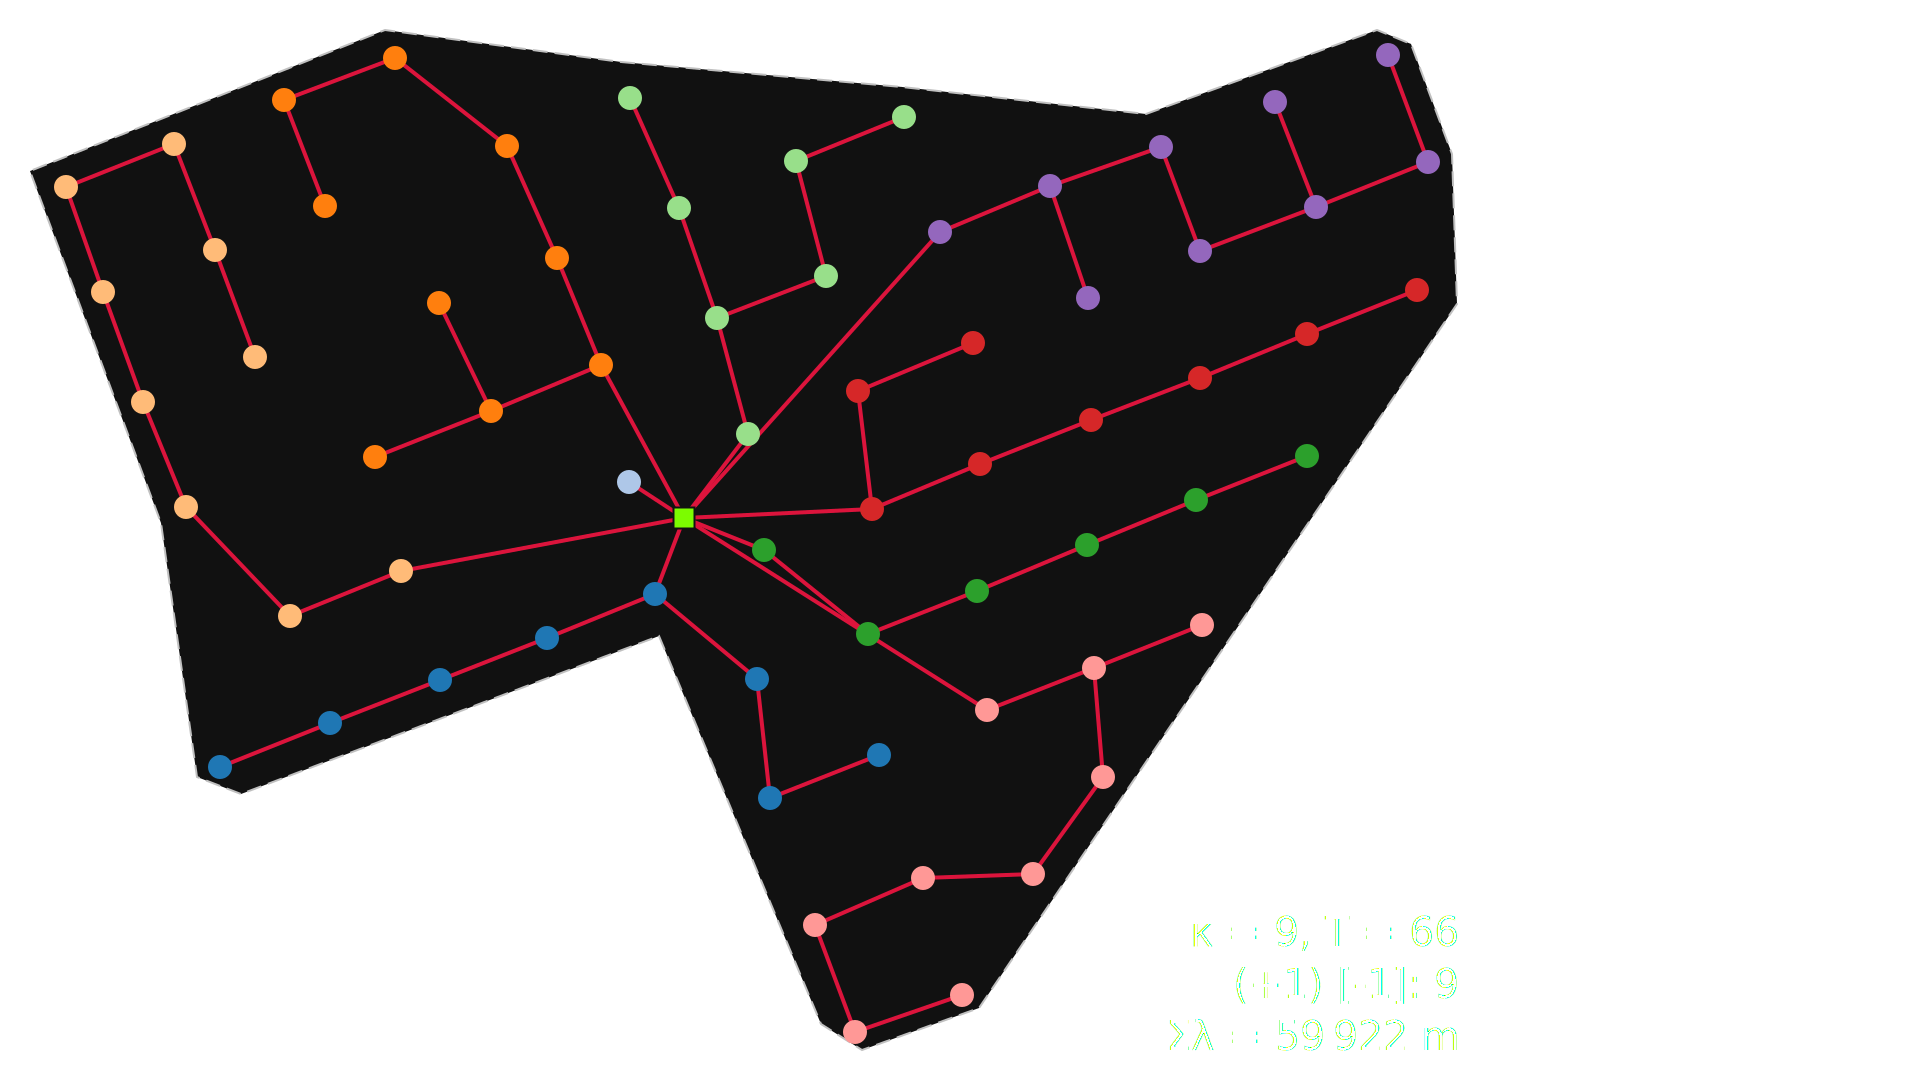

CPEW: constructor


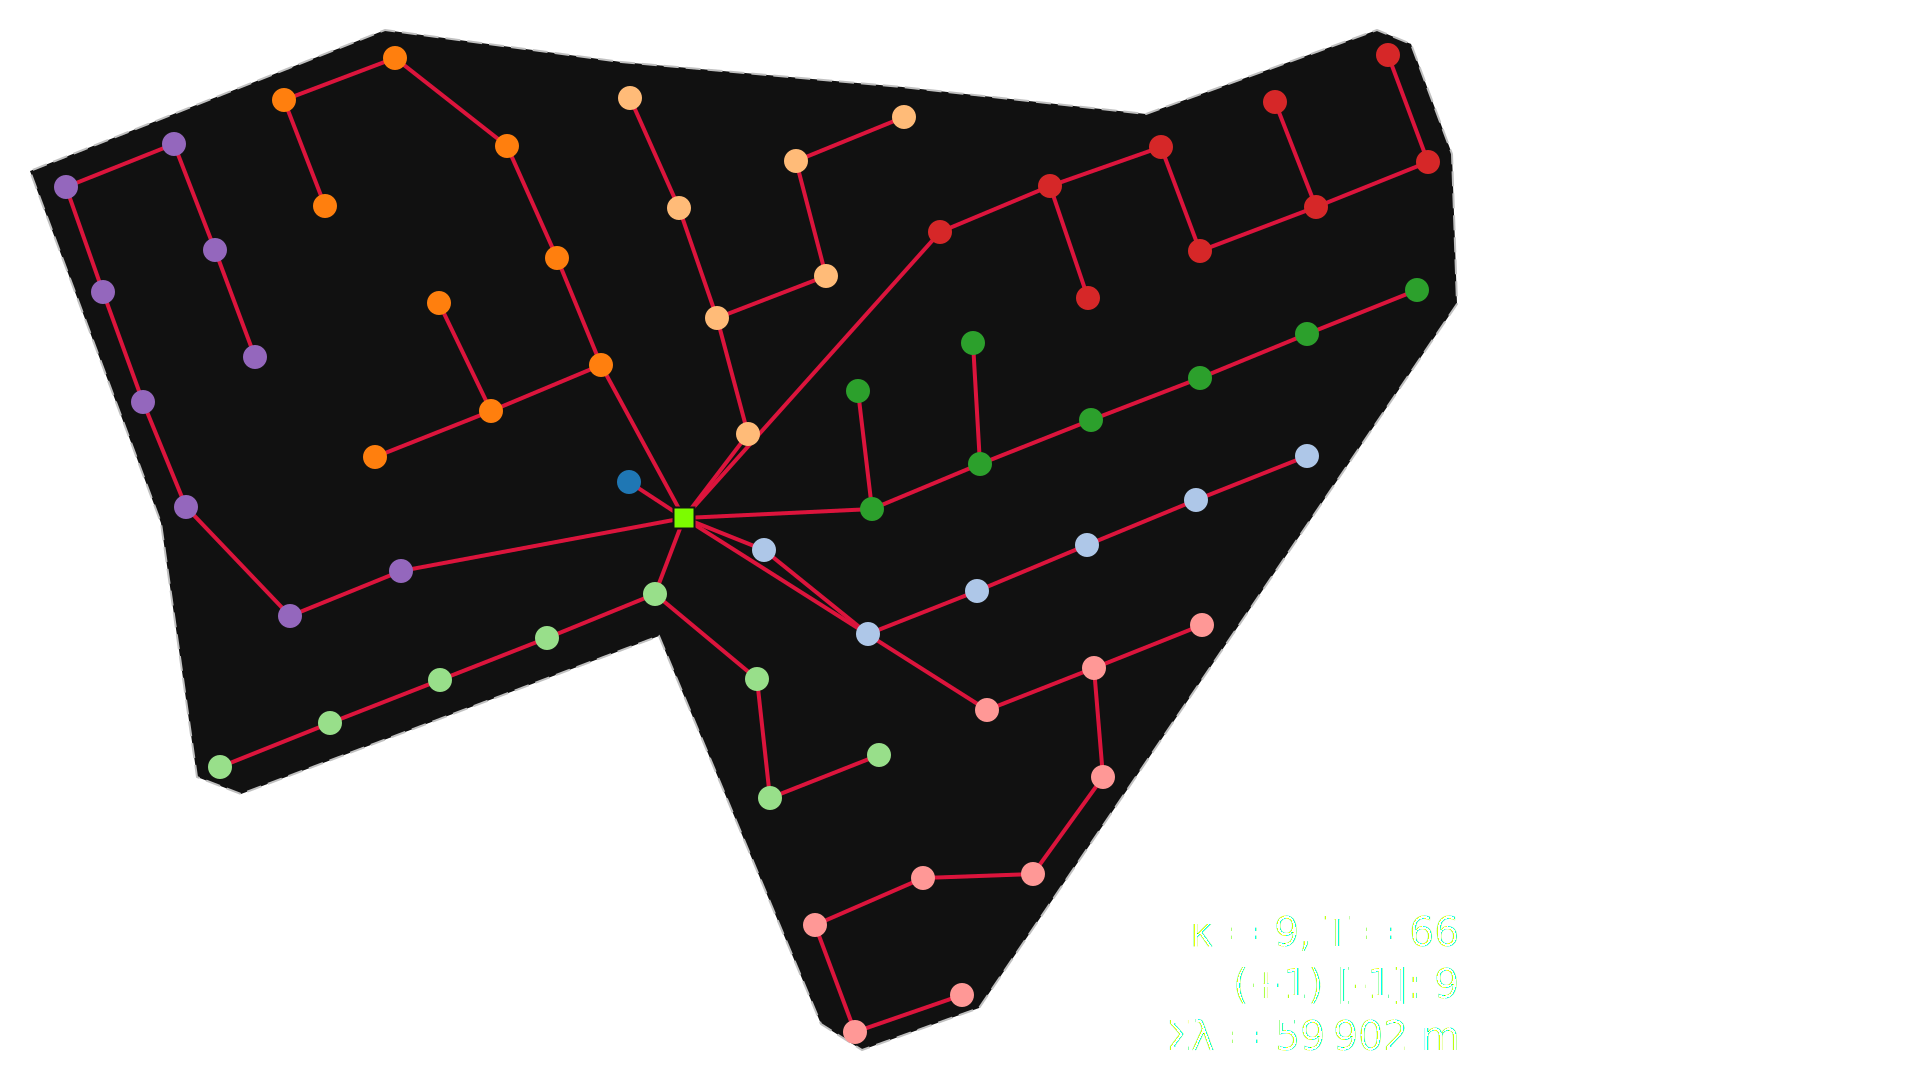

In [7]:
show_pair('CPEW', G_cpew, G_constructor_cpew)

### Non-Branching Esau-Williams

In [8]:
L = locations.sofia
capacity = 9

G_nbew = legacy_solution(NBEW, L, capacity)
G_constructor_nbew = constructor_solution(
    L,
    capacity,
    method='radial_EW',
    straight_feeder_route=True,
    weigh_detours=False,
)

compare('NBEW', G_nbew, G_constructor_nbew)

{'case': 'NBEW',
 'legacy_length': 275479,
 'constructor_length': 274287,
 'legacy_max_load': 9,
 'constructor_max_load': 9}

NBEW: legacy


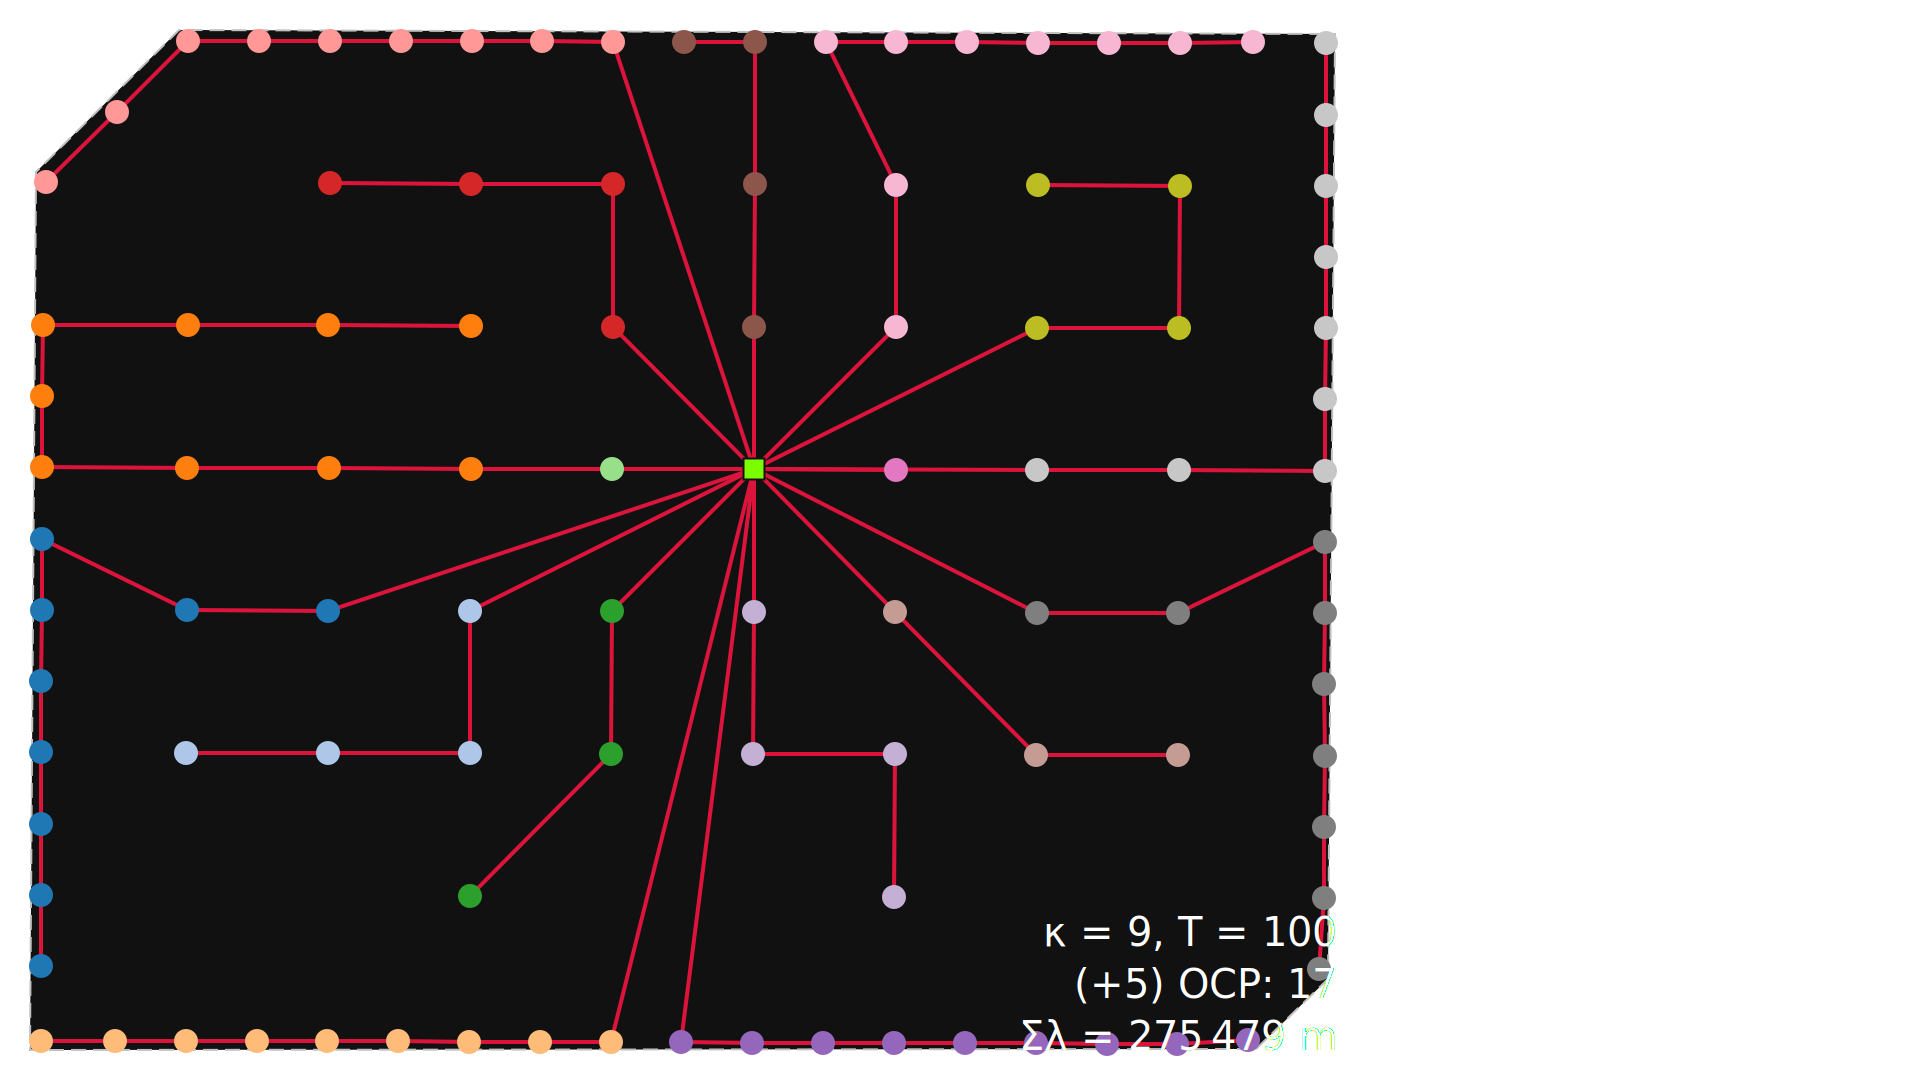

NBEW: constructor


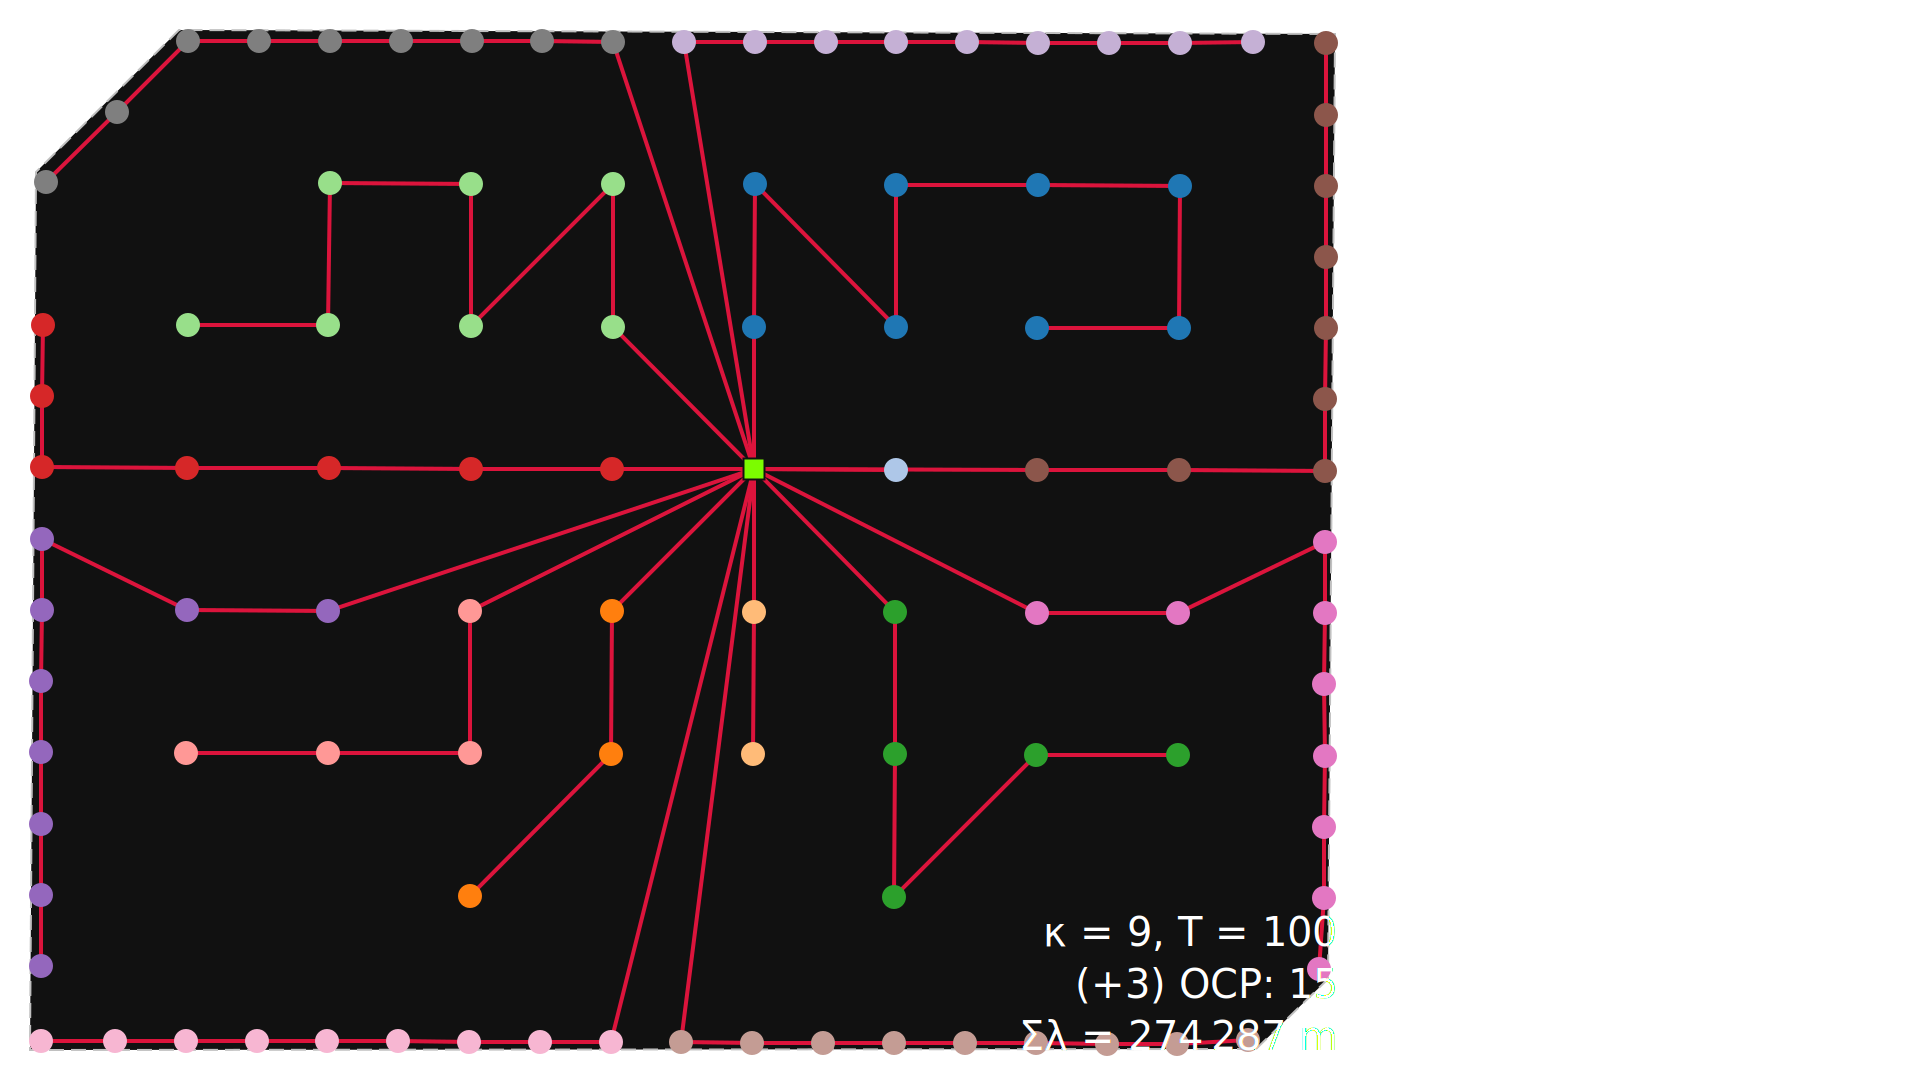

In [9]:
show_pair('NBEW', G_nbew, G_constructor_nbew)

### Obstacle-Bypassing Esau-Williams

In [10]:
L = locations.borkum2
capacity = 6

G_obew = legacy_solution(OBEW, L, capacity, rootlust='0.6*cur_capacity/capacity')
G_constructor_obew = constructor_solution(
    L,
    capacity,
    method='rootlust',
    # matching OBEW's rootlust is capacity-dependent
    rootlust_=(0.0, 0.6 * (capacity - 1) / capacity),
)

compare('OBEW rootlust', G_obew, G_constructor_obew)

{'case': 'OBEW rootlust',
 'legacy_length': 58916,
 'constructor_length': 59187,
 'legacy_max_load': 6,
 'constructor_max_load': 6}

OBEW rootlust: legacy


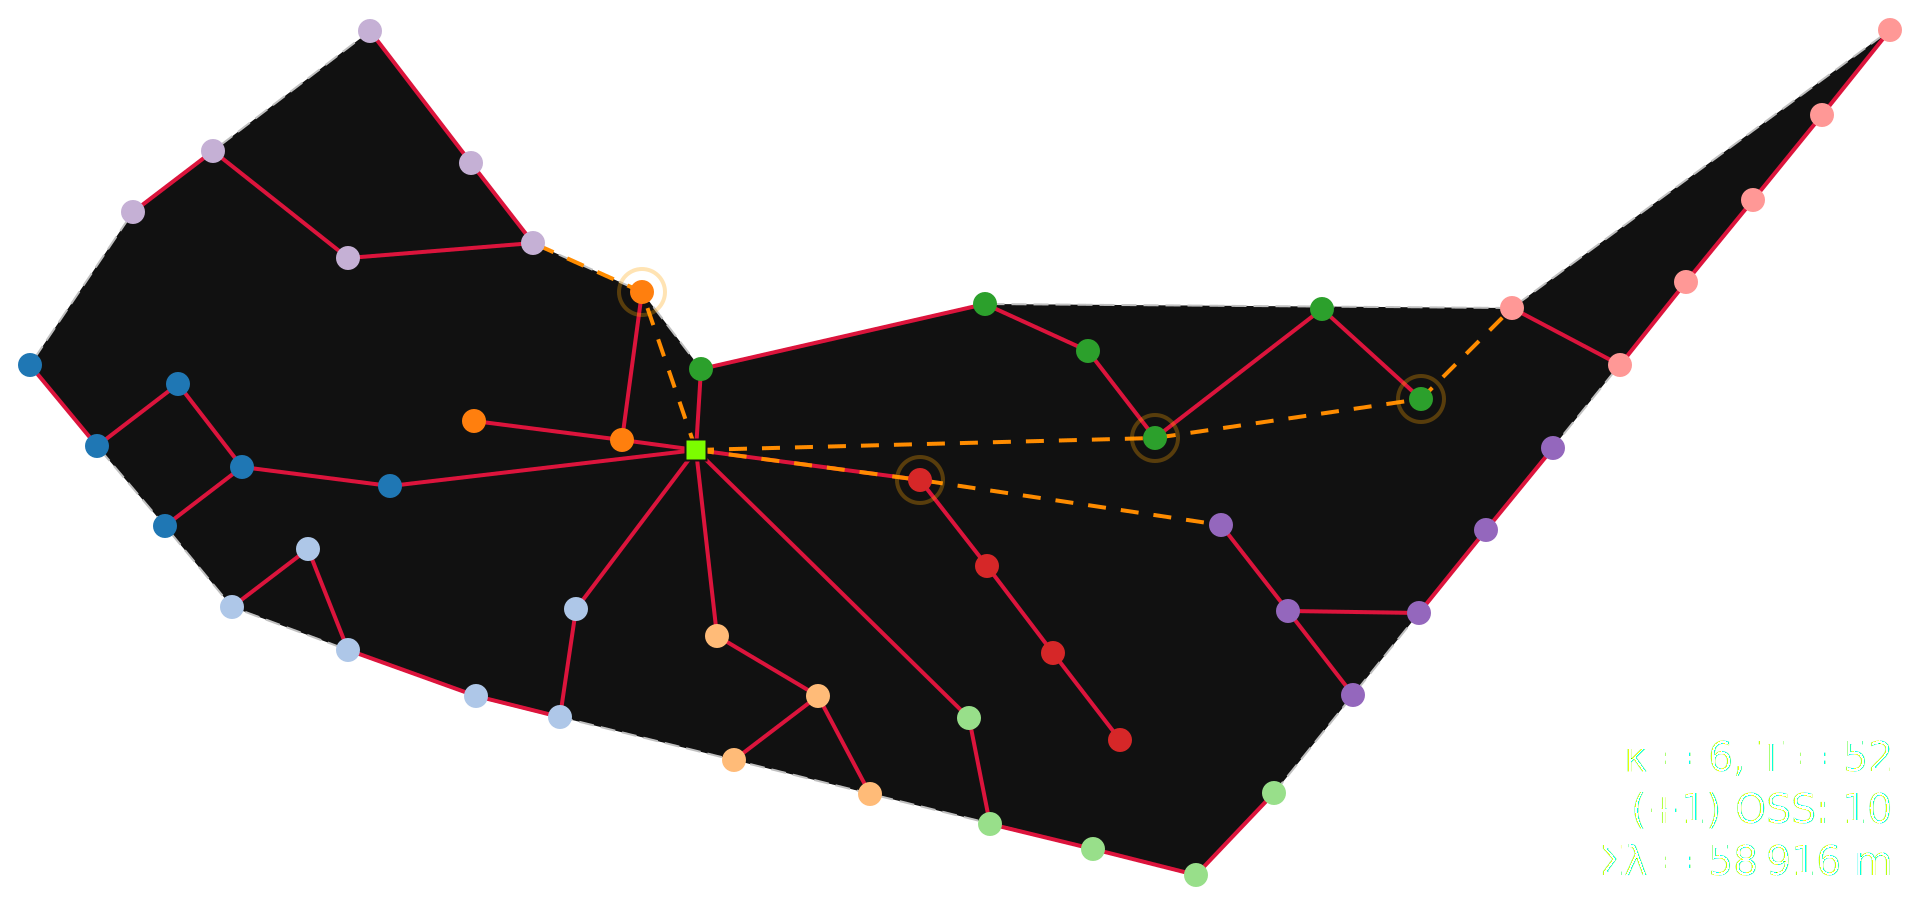

OBEW rootlust: constructor


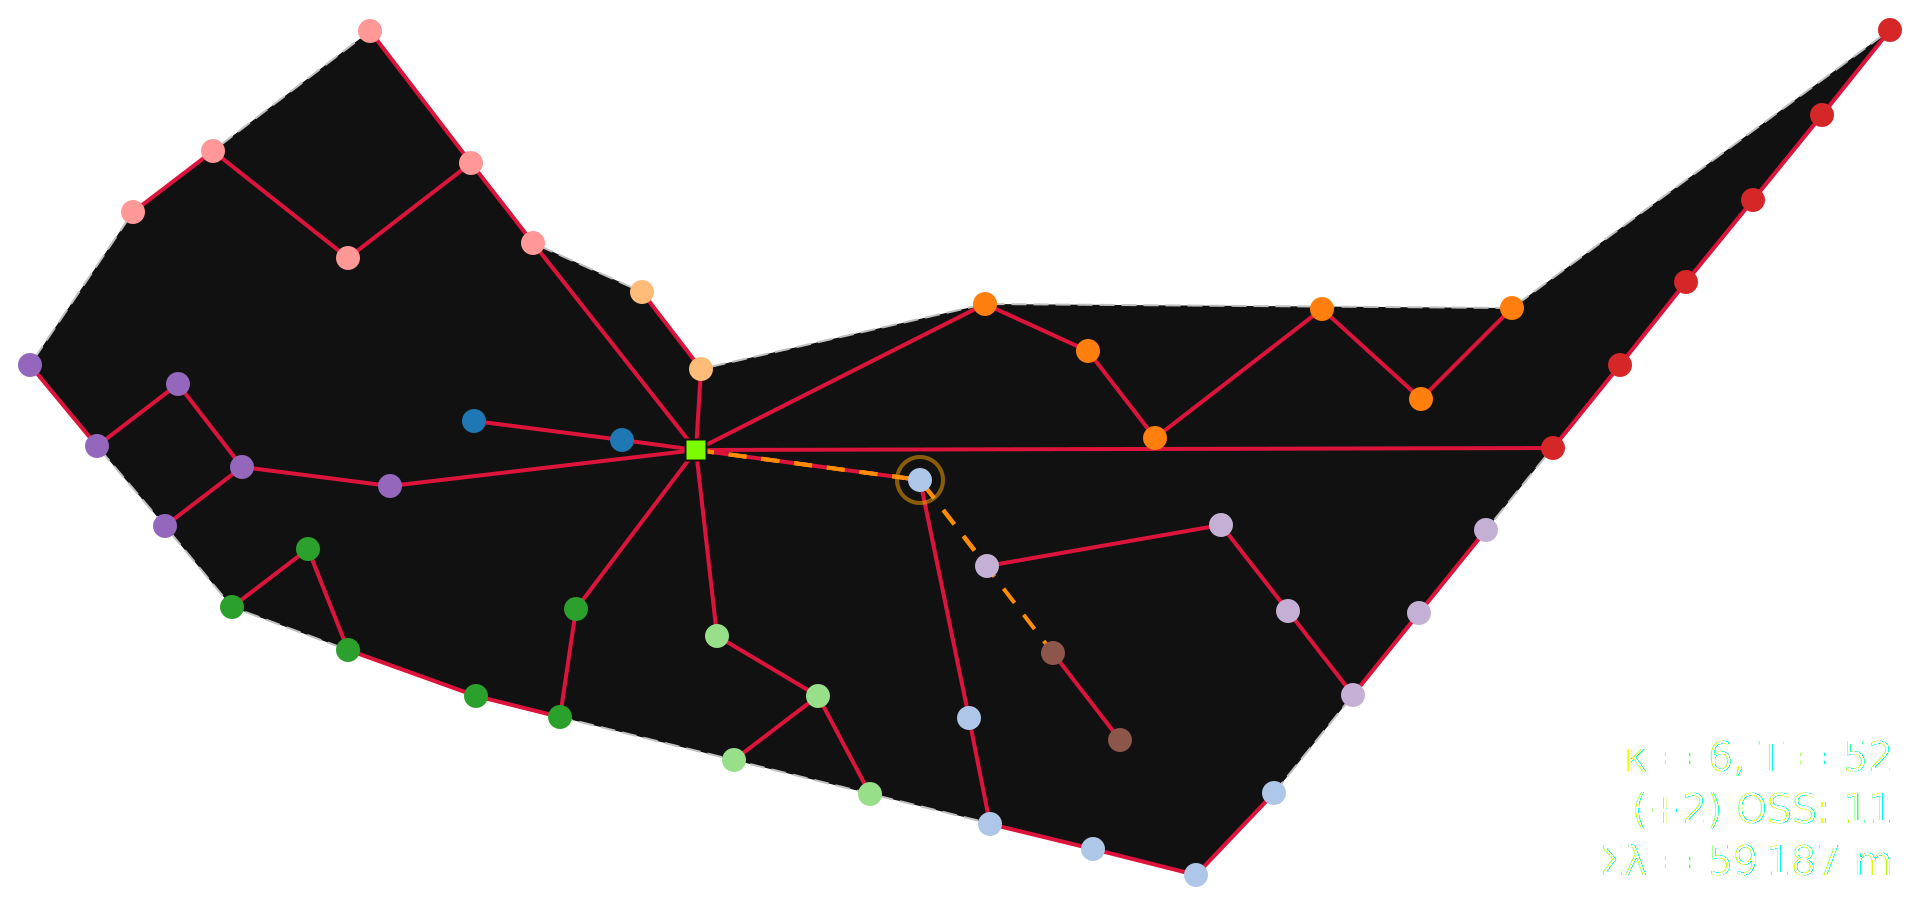

In [11]:
show_pair('OBEW rootlust', G_obew, G_constructor_obew)

In [12]:
G_obew_default = legacy_solution(OBEW, L, capacity)
G_constructor_obew_default = constructor_solution(L, capacity, method='biased_EW')

compare('OBEW default', G_obew_default, G_constructor_obew_default)

{'case': 'OBEW default',
 'legacy_length': 58275,
 'constructor_length': 58275,
 'legacy_max_load': 6,
 'constructor_max_load': 6}

OBEW default: legacy


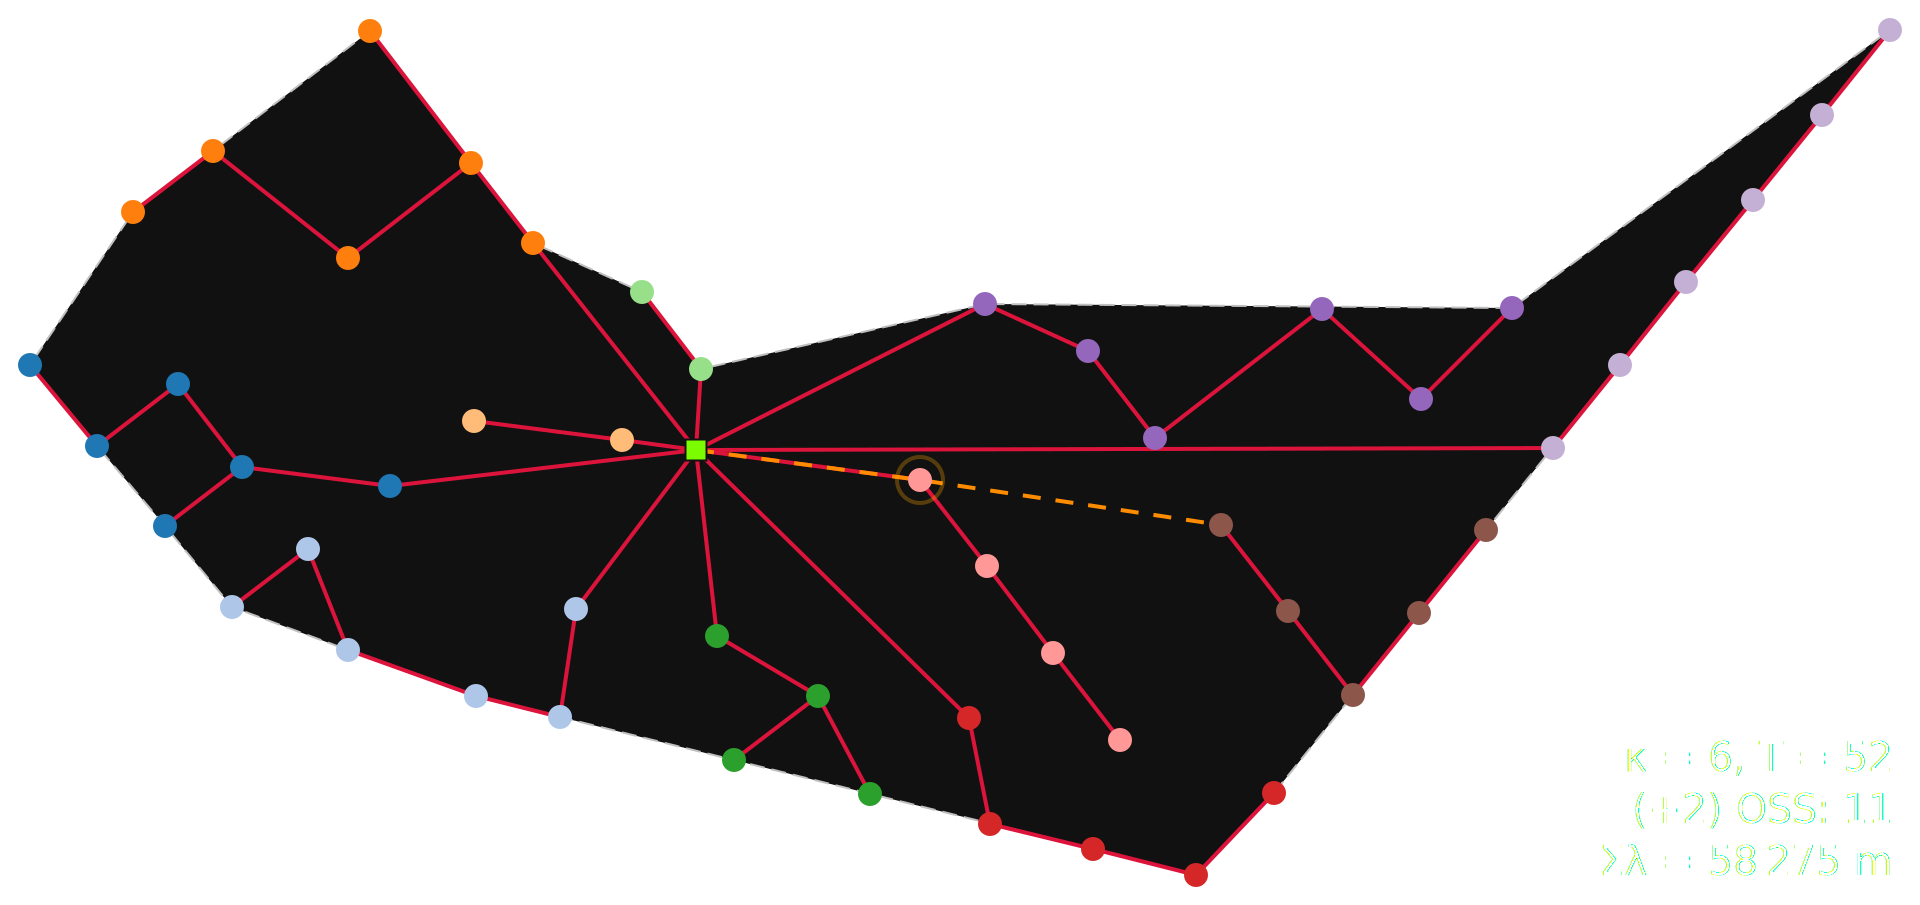

OBEW default: constructor


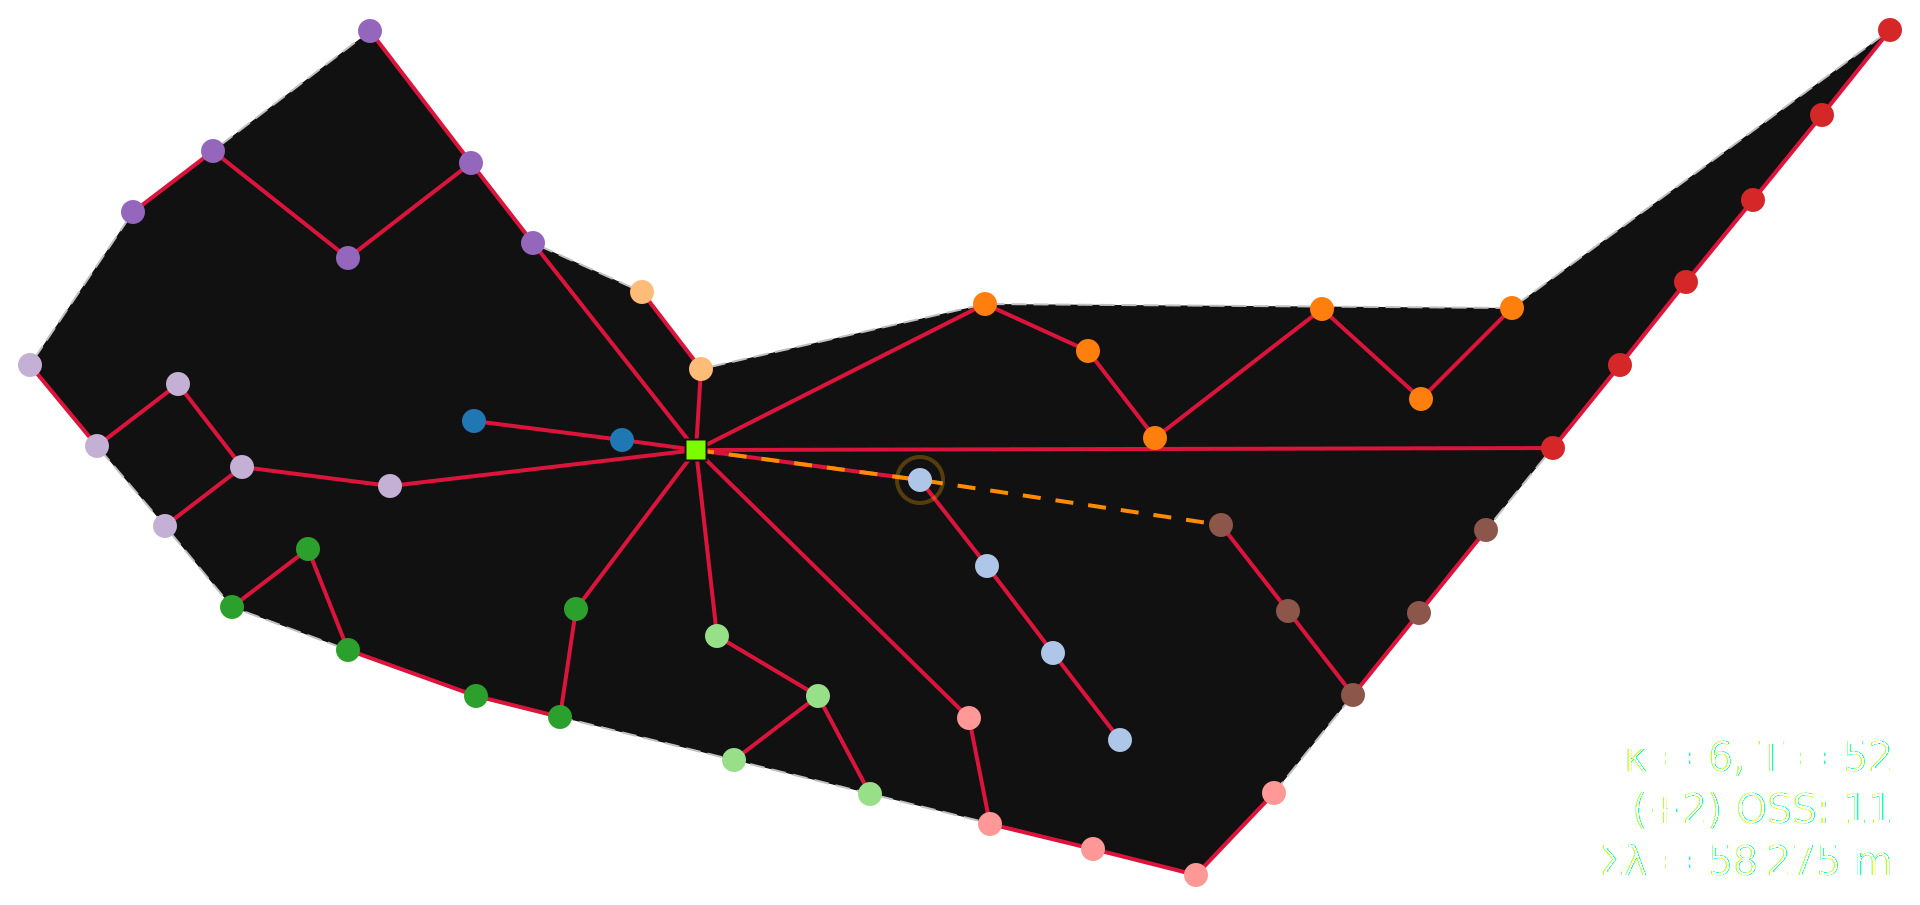

In [13]:
show_pair('OBEW default', G_obew_default, G_constructor_obew_default)